<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/KNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pratikshasatishpawar","key":"2ef9c3c4292e80755255fcdd46578070"}'}

In [ ]:
import os

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move kaggle (3).json to the correct location and rename it to kaggle.json
!cp '/content/kaggle.json' ~/.kaggle/kaggle.json

# Set appropriate permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
 99% 1.43G/1.45G [00:22<00:00, 288MB/s]
100% 1.45G/1.45G [00:22<00:00, 68.2MB/s]


In [ ]:
!unzip wildfire-prediction-dataset.zip -d wildfire_data

Streaming output truncated to the last 5000 lines.
  inflating: wildfire_data/valid/nowildfire/-73.465183,45.443641.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.465388,45.584881.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.469451,45.480331.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.471252,45.51974.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.472693,45.427766.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.473015,45.435254.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.475051,45.56612.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.477079,45.597274.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.478813,45.555686.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.479478,45.524618.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.480135,45.528248.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.480722,45.518864.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.481149,45.563113.jpg  
  inflating: wildfire_data/v

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from PIL import ImageFile

In [ ]:
#Handle truncated image
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
train_dir = "/content/wildfire_data/train"
test_dir = "/content/wildfire_data/test"


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 30250 images belonging to 2 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 6300 images belonging to 2 classes.


In [ ]:
#Model Building
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile the model
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)


Epoch 1/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9872 - loss: 0.0370 - val_accuracy: 0.9648 - val_loss: 0.1604
Epoch 2/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9880 - loss: 0.0365 - val_accuracy: 0.9641 - val_loss: 0.1395
Epoch 3/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9856 - loss: 0.0369 - val_accuracy: 0.9579 - val_loss: 0.2130
Epoch 4/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.9893 - loss: 0.0310 - val_accuracy: 0.9633 - val_loss: 0.2508
Epoch 5/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9902 - loss: 0.0272 - val_accuracy: 0.9625 - val_loss: 0.2817
Epoch 6/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9891 - loss: 0.0293 - val_accuracy: 0.9671 - val_loss: 0.2144
Epoch 7/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9903 - loss: 0.0247 - val_accuracy: 0.9044 - val_loss: 0.4152
Epoch 8/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 86s 66ms/step - accuracy: 0.9866 - loss: 0.0387 - 

In [ ]:
#model evaluation
loss,accuracy=model.evaluate(test_generator)
print(f"Test Accuracy:{accuracy*100:.2f}%")


197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9640 - loss: 0.2381
Test Accuracy:96.40%


In [ ]:
#prediction
predictions = model.predict(test_generator)
y_pred=(predictions>0.5).astype(int)
y_true= test_generator.classes

197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step


In [ ]:
# classification report and confusion matrix
print("Classification Report:\n", classification_report(y_true,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.47      0.46      2820
           1       0.56      0.54      0.55      3480

    accuracy                           0.51      6300
   macro avg       0.51      0.51      0.51      6300
weighted avg       0.51      0.51      0.51      6300

Confusion Matrix:
 [[1324 1496]
 [1591 1889]]


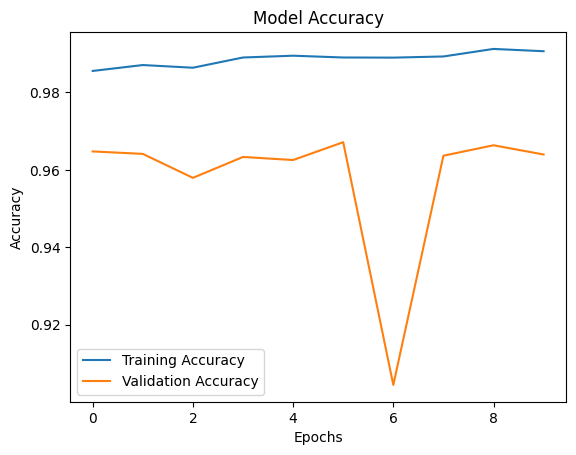

In [ ]:
#Plotting training history
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import joblib
joblib.dump(model,'forest_fire_model.pkl')


['forest_fire_model.pkl']

In [ ]:
model.save('forest_fire_model.h5')

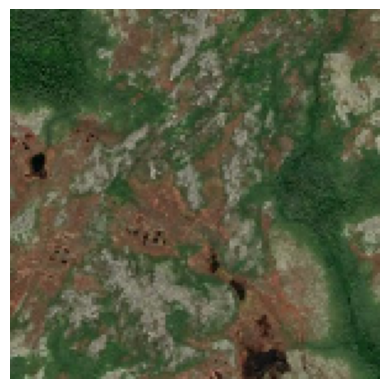

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Wildfire


In [ ]:
from tensorflow.keras.preprocessing import image

def predict_and_show_image(image_path):
  img= image.load_img(image_path,target_size=(150,150))
  img_array = image.img_to_array(img)/255.0
  img_array= np.expand_dims(img_array,axis=0)

  plt.imshow(img)
  plt.axis('off')
  plt.show()

  prediction = model.predict(img_array)
  print("Prediction:","Wildfire" if prediction[0]>0.5 else "No Wildfire")
predict_and_show_image("/content/wildfire_data/test/wildfire/-60.73875,50.24761.jpg")